In [1]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer

In [2]:
df = pd.read_csv(
    "potential-talents - Aspiring human resources - seeking human resources.csv"
)

print("Original dataset shape:", df.shape)

df.head()

Original dataset shape: (104, 5)


,id,job_title,location,connection,fit
0,1,2019 C.T. Bauer College of Business Graduate (...,"Houston, Texas",85,NaN
1,2,Native English Teacher at EPIK (English Progra...,Kanada,500+,NaN
2,3,Aspiring Human Resources Professional,"Raleigh-Durham, North Carolina Area",44,NaN
3,4,People Development Coordinator at Ryan,"Denton, Texas",500+,NaN
4,5,Advisory Board Member at Celal Bayar University,"İzmir, Türkiye",500+,NaN


In [3]:
df = df.drop_duplicates(
    subset=df.columns.drop("id")
).reset_index(drop=True)

print("After removing duplicates:", df.shape)

After removing duplicates: (53, 5)


In [4]:
def clean_connection(x):
    x = str(x)

    if "500+" in x:
        return 500

    return int(x)

df["connection"] = df["connection"].apply(clean_connection)

df["connection"].describe()

,connection
count,53.000000
mean,241.905660
std,217.064796
min,1.000000
25%,44.000000
50%,155.000000
75%,500.000000
max,500.000000


In [5]:
def clean_text(text):
    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z ]', ' ', text)

    text = re.sub(r'\s+', ' ', text)

    return text.strip()

df["job_title"] = df["job_title"].apply(clean_text)

df["location"] = df["location"].apply(clean_text)

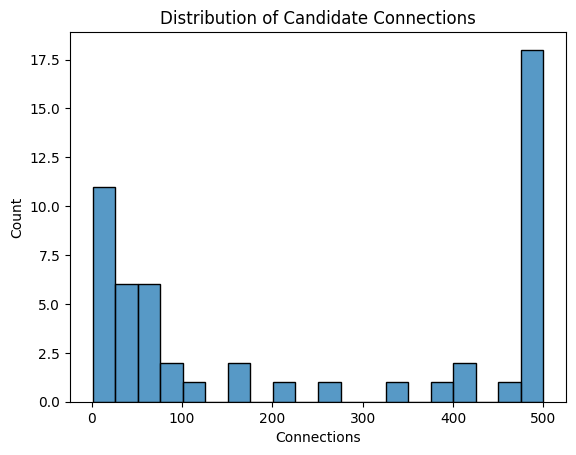

In [6]:
sns.histplot(df["connection"], bins=20)

plt.title("Distribution of Candidate Connections")

plt.xlabel("Connections")

plt.show()

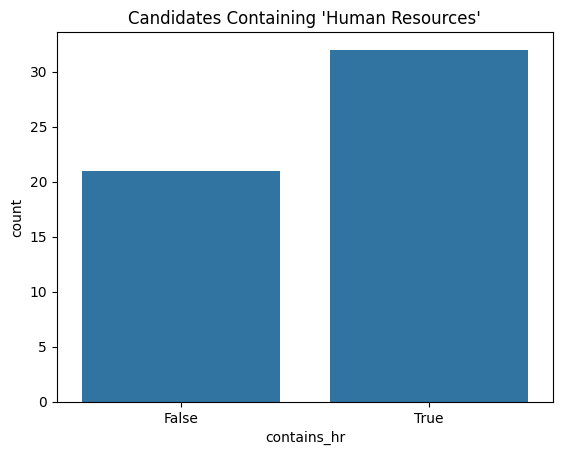

Candidates containing HR: 32


In [7]:
df["contains_hr"] = df["job_title"].str.contains(
    "human resources"
)

sns.countplot(x="contains_hr", data=df)

plt.title("Candidates Containing 'Human Resources'")

plt.show()

print(
    "Candidates containing HR:",
    df["contains_hr"].sum()
)

In [8]:
keywords = [
    "aspiring human resources",
    "seeking human resources"
]

keyword_text = " ".join(keywords)

In [9]:
model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [10]:
job_embeddings = model.encode(
    df["job_title"].tolist()
)

keyword_embedding = model.encode(
    [keyword_text]
)

In [11]:
df["similarity"] = cosine_similarity(
    job_embeddings,
    keyword_embedding
).flatten()

In [12]:
df["connection_score"] = (
    df["connection"] /
    df["connection"].max()
)

In [13]:
df["initial_fit"] = (
    0.85 * df["similarity"] +
    0.15 * df["connection_score"]
)

In [14]:
initial_ranked = df.sort_values(
    by="initial_fit",
    ascending=False
)

print("Top 10 BEFORE Starring:\n")

print(
    initial_ranked[
        ["id","job_title","initial_fit"]
    ].head(10)
)

Top 10 BEFORE Starring:

     id                                          job_title  initial_fit
13   28              seeking human resources opportunities     0.825138
45   97              aspiring human resources professional     0.776519
8    10  seeking human resources hris and generalist po...     0.775874
2     3              aspiring human resources professional     0.768419
12   27  aspiring human resources management student se...     0.765223
15   67  human resources staffing and recruiting profes...     0.754549
5     6                aspiring human resources specialist     0.739872
47   99                   seeking human resources position     0.705039
30   82  aspiring human resources professional an energ...     0.663605
48  100  aspiring human resources manager graduating ma...     0.650450


In [15]:
starred_id = 3

star_index = df[
    df["id"] == starred_id
].index[0]

star_vector = job_embeddings[
    star_index
]

In [16]:
df["star_similarity"] = cosine_similarity(
    job_embeddings,
    [star_vector]
).flatten()

In [17]:
df["final_score"] = (
    0.6 * df["initial_fit"] +
    0.4 * df["star_similarity"]
)

final_ranked = df.sort_values(
    by="final_score",
    ascending=False
)

print("\nTop 10 AFTER Starring:\n")

print(
    final_ranked[
        ["id","job_title","final_score"]
    ].head(10)
)


Top 10 AFTER Starring:

    id                                          job_title  final_score
45  97              aspiring human resources professional     0.865912
2    3              aspiring human resources professional     0.861052
5    6                aspiring human resources specialist     0.823389
13  28              seeking human resources opportunities     0.796897
15  67  human resources staffing and recruiting profes...     0.772741
8   10  seeking human resources hris and generalist po...     0.760361
12  27  aspiring human resources management student se...     0.742183
47  99                   seeking human resources position     0.736400
30  82  aspiring human resources professional an energ...     0.731819
22  74                       human resources professional     0.724030


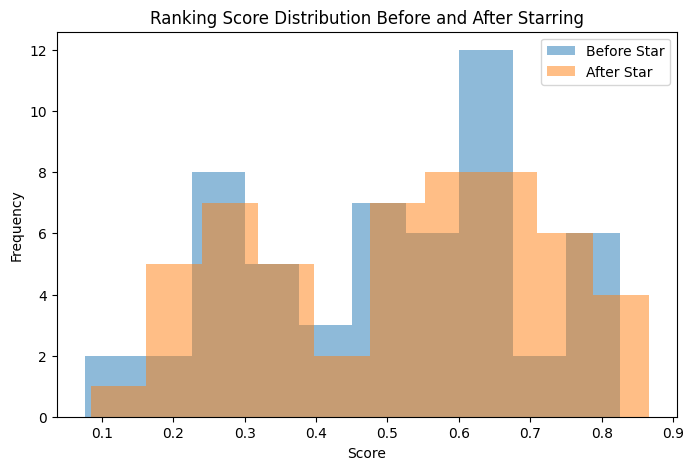

In [18]:
plt.figure(figsize=(8,5))

plt.hist(
    df["initial_fit"],
    alpha=0.5,
    label="Before Star"
)

plt.hist(
    df["final_score"],
    alpha=0.5,
    label="After Star"
)

plt.legend()

plt.title(
    "Ranking Score Distribution Before and After Starring"
)

plt.xlabel("Score")

plt.ylabel("Frequency")

plt.show()

In [19]:
threshold = 0.25

filtered_df = df[
    (df["initial_fit"] > threshold) |
    (df["contains_hr"] == True)
]

print(
    "Candidates remaining after filtering:",
    filtered_df.shape[0]
)

Candidates remaining after filtering: 48


In [20]:
cutoff = df["initial_fit"].quantile(0.75)

filtered_dynamic = df[
    df["initial_fit"] >= cutoff
]

print(
    "Dynamic Cutoff Used:",
    cutoff
)

print(
    "Candidates after dynamic cutoff:",
    filtered_dynamic.shape[0]
)

Dynamic Cutoff Used: 0.6421770545005798
Candidates after dynamic cutoff: 14


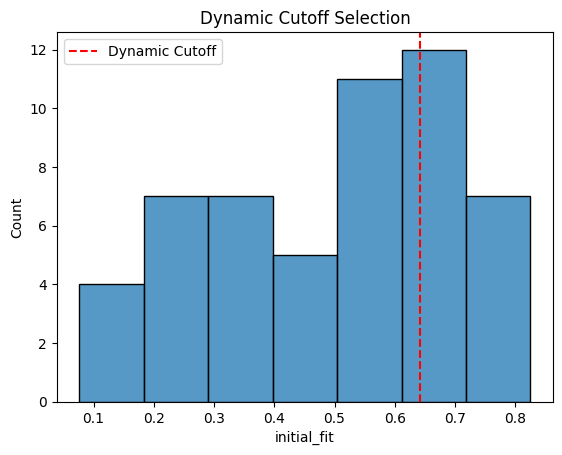

In [21]:
sns.histplot(df["initial_fit"])

plt.axvline(
    cutoff,
    color="red",
    linestyle="--",
    label="Dynamic Cutoff"
)

plt.legend()

plt.title("Dynamic Cutoff Selection")

plt.show()

In [22]:
star_ids = [3, 10, 25]

star_indices = df[
    df["id"].isin(star_ids)
].index

star_vectors = job_embeddings[
    star_indices
]

multi_star_similarity = cosine_similarity(
    job_embeddings,
    star_vectors
).mean(axis=1)

df["multi_star_score"] = (
    0.6 * df["initial_fit"] +
    0.4 * multi_star_similarity
)

multi_star_ranked = df.sort_values(
    by="multi_star_score",
    ascending=False
)

print(
    "Top Candidates using Multi-Star Ranking:\n"
)

print(
    multi_star_ranked[
        ["id","job_title","multi_star_score"]
    ].head(10)
)

Top Candidates using Multi-Star Ranking:

    id                                          job_title  multi_star_score
45  97              aspiring human resources professional          0.813330
8   10  seeking human resources hris and generalist po...          0.812943
2    3              aspiring human resources professional          0.808470
13  28              seeking human resources opportunities          0.799401
5    6                aspiring human resources specialist          0.787206
15  67  human resources staffing and recruiting profes...          0.753416
47  99                   seeking human resources position          0.750014
12  27  aspiring human resources management student se...          0.720914
30  82  aspiring human resources professional an energ...          0.690989
22  74                       human resources professional          0.686142


In [23]:
print("Original dataset:", df.shape[0])

print(
    "After threshold filtering:",
    filtered_df.shape[0]
)

print(
    "After dynamic cutoff:",
    filtered_dynamic.shape[0]
)

Original dataset: 53
After threshold filtering: 48
After dynamic cutoff: 14


In [24]:
final_ranked.to_csv(
    "final_ranked_sbert_candidates.csv",
    index=False
)

multi_star_ranked.to_csv(
    "multi_star_ranked_candidates.csv",
    index=False
)